Introduction:

Sabrina and I are Microbiology majors, and have served as teaching assistants for MCB3023L; a core Microbiology laboratory class. A key part of the class is the lab practical, which constitutes a large part of the students' grades. It is notorious for being long and difficult.

We wanted to investigate factors potentially related to performance on the lab practical so that we could help our professor and her future students.

Data Collection:

We started off by creating a survey for MCB3023L asking several questions related to 1) their letter grade performance on the practical and 2) their studying/learning habits related to the lab practical.


Now, to help you get an idea of what the survey was like, here is a look at the questions asked on the survey: 

How often did you pay close attention during lab sessions?

How many times did you come into the lab outside of class to practice techniques?

How confident were you in your lab techniques before the practical? (rate 1-5 )

How anxious were you about the lab practical? (rate 1-5 )

How many hours per week did you study or review lab materials?

Helpfulness in Studying: Lab Manual (rate 1-5 stars)

Helpfulness in Studying: Quizlet (rate 1-5 stars)

Helpfulness in Studying: Lab Slides (rate 1-5 stars)

Helpfulness in Studying: ELNs (rate 1-5 stars)

Helpfulness in Studying: ChatGPT (rate 1-5 stars)

Do you or have you worked or volunteered in a lab setting outside of MCB3023L? (yes or no)

What grade did you receive on the lab practical? ← (Target!! What we want to predict!! Asked as Letter Grade, not Numerical grade)

We then had to obtain IRB-exemption (since we were collecting data off of people) and sponsorship from our professor of whom we TA'd for. It could be argued that we don't actually need this since this is for educational purposes and not for research publication, but we decided we would do this for ethical purposes, just in case. 

Additionally, all the data collected was anonymous.


Survey Distribution: 

The next part involved contacting three professors who teach MCB3023L and requesting they distribute the survey to their students. It was the most essential part of our project. Without data, we don't really have a solid project. Additionally, the number of responses we got largely impacts what models we can even consider using. 

We ended up collecting 82 responses total. Was it what we wanted? No. But this is how the real world works sometimes, and so we had to make do. 

Because of how many responses we got, we decided we could NOT use a deep neural network. We would have to stick with using Logistic Regression, Random Forest, and Decision Trees.

## Data Preprocessing: Load & Clean Columns

Okay so first we’re loading in the CSV file from our survey. Some of the column names are way too long and arguably annoying to work with, so we’re renaming them to something easier. We’re also dropping the timestamp and the confirmation checkbox since they’re not useful for our analysis. Those are just the questions that address when the person took the survey and if they want to take the survey.


In [1]:
import pandas as pd

# Load the raw CSV file
df = pd.read_csv("MCB3032L (Responses) - Form Responses final.csv")

# Rename columns to something more readable
df.columns = [
    "timestamp",
    "attention_during_lab",
    "lab_practice_times",
    "confidence_before_practical",
    "anxiety_about_practical",
    "study_hours_per_week",
    "helpfulness_lab_manual",
    "helpfulness_quizlet",
    "helpfulness_lab_slides",
    "helpfulness_eln",
    "helpfulness_chatgpt",
    "prior_lab_experience",
    "lab_practical_grade",
    "survey_confirmation"
]

# Drop unnecessary columns
df = df.drop(columns=["timestamp", "survey_confirmation"], errors="ignore")

# Display the first few rows
df.head()


,attention_during_lab,lab_practice_times,confidence_before_practical,anxiety_about_practical,study_hours_per_week,helpfulness_lab_manual,helpfulness_quizlet,helpfulness_lab_slides,helpfulness_eln,helpfulness_chatgpt,prior_lab_experience,lab_practical_grade
0,most of the time,0 times,5,3,less than 1 hour,3.0,1.0,4.0,5,1.0,yes,A (90-100)
1,most of the time,2-3 times,5,2,1-2 hours,1.0,1.0,2.0,1,1.0,yes,D (60-69)
2,most of the time,2-3 times,4,2,1-2 hours,3.0,1.0,5.0,5,4.0,yes,B (80-89)
3,most of the time,2-3 times,3,3,less than 1 hour,2.0,2.0,5.0,4,1.0,yes,B (80-89)
4,most of the time,2-3 times,3,5,less than 1 hour,2.0,1.0,3.0,4,4.0,yes,B (80-89)


## Converting Survey Answers to Numbers

Now we’re going to convert the written responses into numbers. Stuff like “most of the time” and “1-2 hours” needs to be mapped to something a model can understand, as well as to keep some continuity aspects. We made custom mappings for each of these based on how they rank in terms of effort or frequency by making them averages (eg 1-2 hours represented as 1.5 hours)

One example important to note is that we changed the yes or no to binary because the model is not going to understand yes or no, but it will understand 1 and 0s.

We also cleaned up the grade column so it just says A, B, C, D, or F.


In [2]:
# Define mappings
attention_map = {
    "always": 5,
    "most of the time": 4,
    "sometimes": 3,
    "rarely": 2,
    "never": 1
}

lab_practice_map = {
    "0 times": 0,
    "1 time": 1,
    "2-3 times": 2.5,
    "4-5 times": 4.5,
    "6+ times": 6
}

study_hours_map = {
    "less than 1 hour": 0.5,
    "1-2 hours": 1.5,
    "3-4 hours": 3.5,
    "5+ hours": 5
}

lab_experience_map = {
    "yes": 1,
    "no": 0
}

# Apply the mappings
df["attention_during_lab"] = df["attention_during_lab"].str.strip().str.lower().map(attention_map)
df["lab_practice_times"] = df["lab_practice_times"].str.strip().map(lab_practice_map)
df["study_hours_per_week"] = df["study_hours_per_week"].str.strip().map(study_hours_map)
df["prior_lab_experience"] = df["prior_lab_experience"].str.strip().str.lower().map(lab_experience_map)
df["lab_practical_grade"] = df["lab_practical_grade"].str.extract(r'([A-F])')

# Check the cleaned version
df.head()


,attention_during_lab,lab_practice_times,confidence_before_practical,anxiety_about_practical,study_hours_per_week,helpfulness_lab_manual,helpfulness_quizlet,helpfulness_lab_slides,helpfulness_eln,helpfulness_chatgpt,prior_lab_experience,lab_practical_grade
0,4,0.0,5,3,0.5,3.0,1.0,4.0,5,1.0,1,A
1,4,2.5,5,2,1.5,1.0,1.0,2.0,1,1.0,1,D
2,4,2.5,4,2,1.5,3.0,1.0,5.0,5,4.0,1,B
3,4,2.5,3,3,0.5,2.0,2.0,5.0,4,1.0,1,B
4,4,2.5,3,5,0.5,2.0,1.0,3.0,4,4.0,1,B


## Quick Visuals to Explore the Data

Before we build any models, it’s a good idea to look at the data a bit. Here’s a bar chart showing how many people got each grade, and a boxplot that shows if there’s any pattern between how many hours people studied and what grade they got.


/tmp/ipykernel_2378/1166850151.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="lab_practical_grade", data=df, order=["A", "B", "C", "D", "F"], palette="viridis")


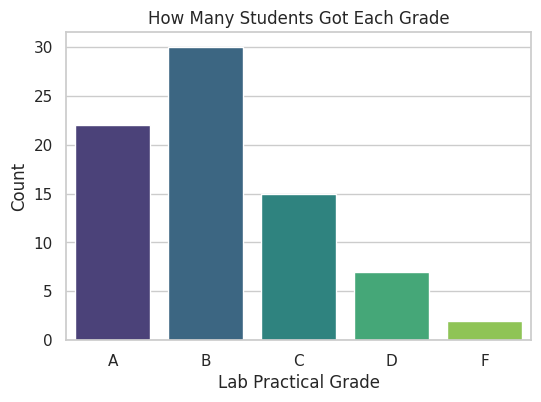

/tmp/ipykernel_2378/1166850151.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="lab_practical_grade", y="study_hours_per_week", data=df, order=["A", "B", "C", "D", "F"], palette="pastel")


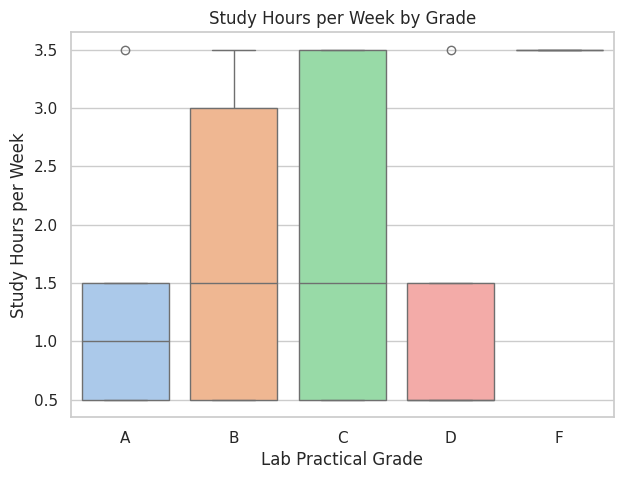

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Bar plot: count of each grade
plt.figure(figsize=(6, 4))
sns.countplot(x="lab_practical_grade", data=df, order=["A", "B", "C", "D", "F"], palette="viridis")
plt.title("How Many Students Got Each Grade")
plt.xlabel("Lab Practical Grade")
plt.ylabel("Count")
plt.show()

# Boxplot: study hours vs grade
plt.figure(figsize=(7, 5))
sns.boxplot(x="lab_practical_grade", y="study_hours_per_week", data=df, order=["A", "B", "C", "D", "F"], palette="pastel")
plt.title("Study Hours per Week by Grade")
plt.xlabel("Lab Practical Grade")
plt.ylabel("Study Hours per Week")
plt.show()


## Looking at All the Features Together

We’re going to make a pairplot now. It shows all the relationships between our features (like confidence, anxiety, study hours, etc.). The dots are colored by what grade the student got. 

This is helpful to spot patterns — like whether higher study hours and confidence cluster around A’s, or if anxiety is all over the place. Even if we don’t get perfect separation, it gives us an idea of what features might matter.


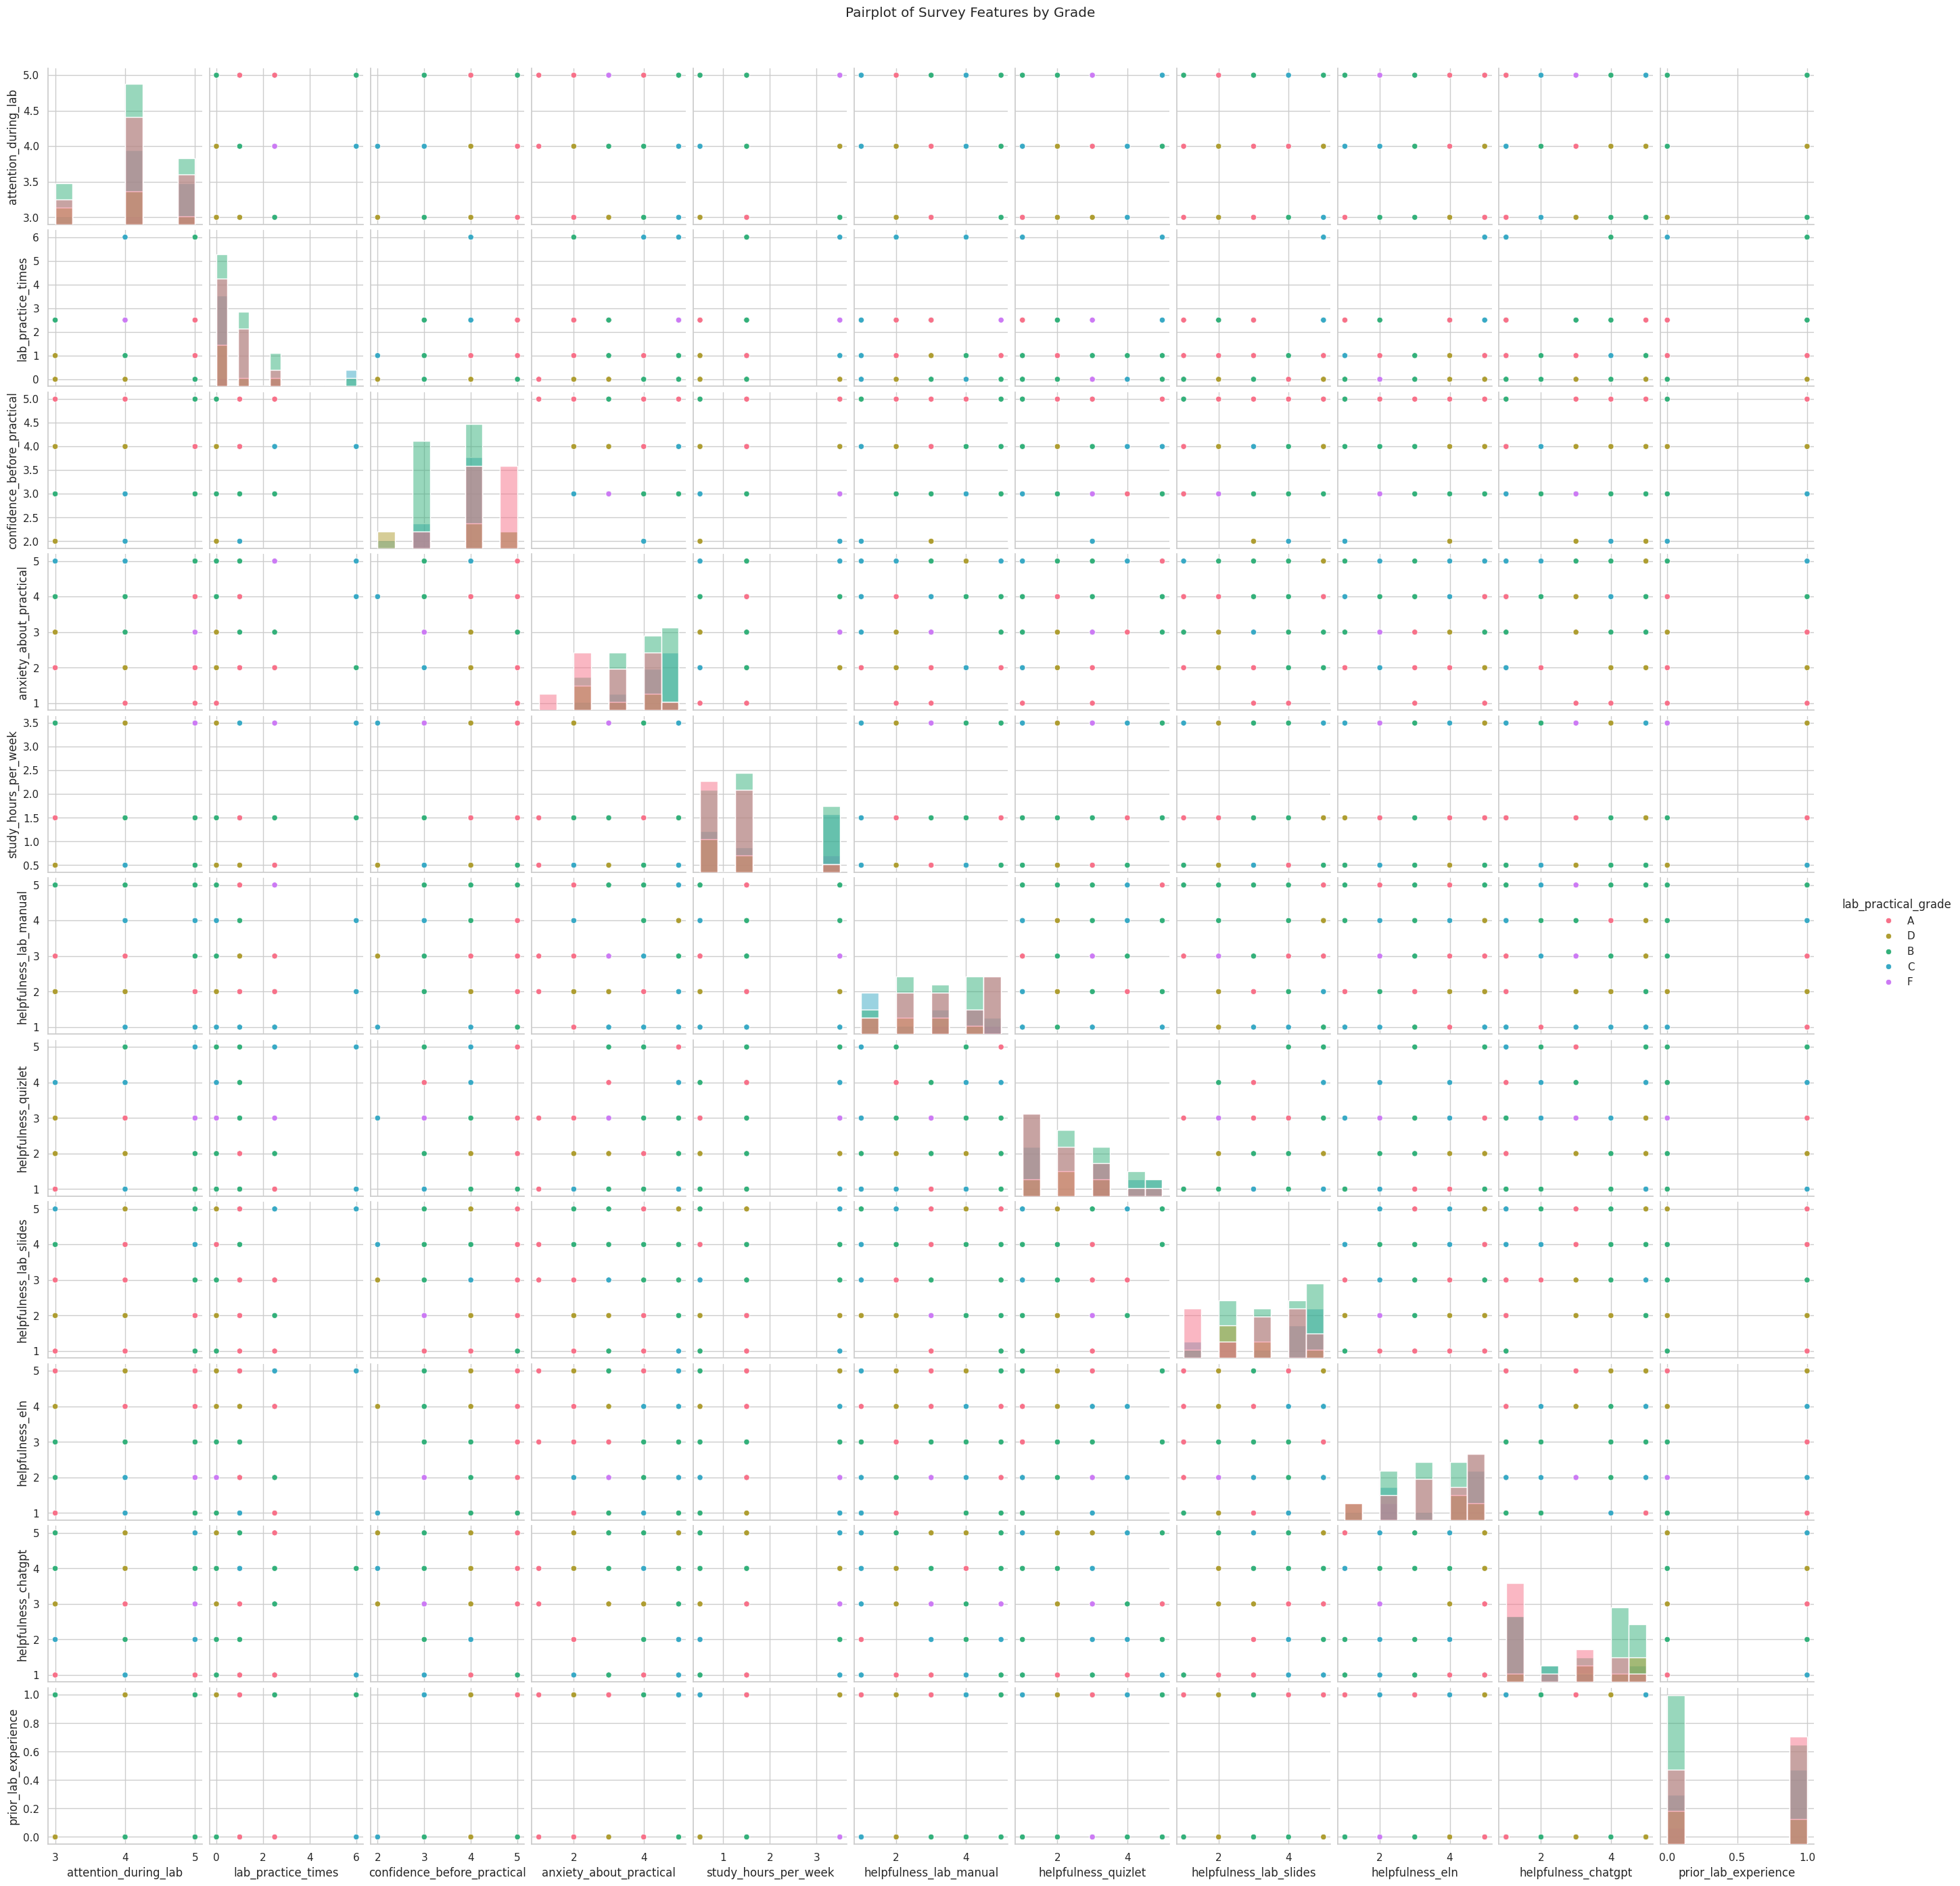

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grab just the numeric features (drop grade for now)
features_for_pairplot = df.drop(columns=["lab_practical_grade"]).select_dtypes(include=[float, int])

# Add grade back in for coloring
pairplot_data = features_for_pairplot.copy()
pairplot_data["lab_practical_grade"] = df["lab_practical_grade"]

# Plot
sns.pairplot(pairplot_data, hue="lab_practical_grade", palette="husl", diag_kind="hist")
plt.suptitle("Pairplot of Survey Features by Grade", y=1.02)
plt.show()


## Quick Look at Some Results So Far

Before we jump into splitting the data or running models, here are a few early visuals based on the cleaned survey data:

- The **grade distribution** shows most students got A’s or B’s, with a few lower grades mixed in.
- The **study hours boxplot** suggests that higher study hours don’t necessarily mean better grades—C students studied more on average than A students.
- The **pairplot** helps us explore relationships between variables. It’s a big messy grid of scatterplots, but sometimes you can see clusters that suggest which variables might help us separate the different grade categories.

We'll keep all of this in mind as we move into modeling.
So yeah, looking at the data... clearly study time alone doesn’t explain who gets an A and who doesn’t. That’s why we’re going to train some to see if we can potentially pick up on patterns that actually matter.
